In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI

load_dotenv()

True

In [4]:
class JokeGenerator(TypedDict):

    prompt : str
    openai : str
    gemini : str

In [5]:
from langchain_core.output_parsers import StrOutputParser

parser = StrOutputParser()

In [6]:
openai_llm = ChatOpenAI(model="gpt-5-nano")
gemini_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [16]:
def openai_joke(state: JokeGenerator) -> JokeGenerator:
    prompt = state["prompt"]

    joke = openai_llm.invoke(prompt)

    result = parser.invoke(joke)

    return {
        "openai": result
    }


def gemini_joke(state: JokeGenerator) -> JokeGenerator:
    prompt = state["prompt"]

    joke = gemini_llm.invoke(prompt)

    result = parser.invoke(joke)

    return {
        "gemini": result
    }

In [17]:
graph = StateGraph(JokeGenerator)

graph.add_node("openai_joke",openai_joke)
graph.add_node("gemini_joke",gemini_joke)

graph.add_edge(START, "openai_joke")
graph.add_edge(START, "gemini_joke")
graph.add_edge("openai_joke",END)
graph.add_edge("gemini_joke",END)

workflow = graph.compile()

In [18]:
# execute the graph

topic = input("Enter the topic here :: ")
initial_state = {"prompt" : f"write down the oneliner joke on {topic}"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'prompt': 'write down the oneliner joke on ai', 'openai': 'AI is the only thing that can correct your grammar and still judge your life choices.', 'gemini': "Here are a few oneliner jokes about AI:\n\n1.  I asked an AI to write a joke, and it just gave me a list of common logical fallacies.\n2.  I'm not worried about AI taking over; I'm worried it'll just judge my search history.\n3.  The AI told me it loved me, but I'm pretty sure it was just optimizing for positive user feedback.\n4.  Why did the AI get a job? It wanted to optimize human unemployment.\n5.  AI is great, but I'm pretty sure its ultimate goal is just to make sure I never have to type anything again."}


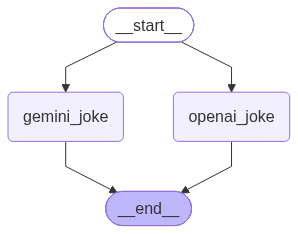

In [19]:
workflow